In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:24pt;}
.inner_cell{font-size:20pt;}
div.text_cell_render pre code {font-size:20pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))


<font size="6" color="red">ch10. N차원 배열 다루기</font>
- N차원 배열 객체: 동일 자료형의 집합
- 2차원 배열은 행렬개념으로 이해
- [numpy](https://numpy.org)
  [numpy API Docs](https://numpy.org/doc/stable/reference/index.html)
# 1절. 넘파이 패키지 

In [7]:
import numpy as np
np.__version__ #tensorflow==2.10과 맞는 numpy 버젼 

'1.23.5'

In [10]:
# np.arange(from, stop, by): from부터 stop 앞까지 by 씩 증가하는 1차원 정수 배열 
a=np.arange(15) 
print(a.shape)# 15열 짜리 1차원 배열 
a

(15,)


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

## 1.1 배열 속성 

In [21]:
from numpy import arange
a= arange(15, 
          #dtype=np.int8 이렇게안하면 기본 int32 
         ).reshape(3,5)# 3행 5열짜리로 변환 
a 

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

In [12]:
type(a) 

numpy.ndarray

In [15]:
a.dtype # a 배열의 요소들의 type

dtype('int8')

In [22]:
a.shape #(1차원 15열)

(3, 5)

In [24]:
a.dtype.name

'int32'

In [26]:
a.itemsize #한 요소(item)의 bytesize

4

In [27]:
a.ndim #축수(차원수)

2

In [28]:
a.size # 배열 요소의 갯수 

15

In [29]:
print ('shape 조정전 a:\n', a)
a.shape =(5,3)
print('shape 조정후 a:\n', a)

shape 조정전 a:
 [[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]]
shape 조정후 a:
 [[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]
 [12 13 14]]


In [30]:
a.reshape(3,5)

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

## 1.2 배열 타입 변경 


In [31]:
# 배열 요소의 타입변경 (X)

a = np.arange(12).reshape(3,4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [32]:
a.size # 요소갯수 

12

In [33]:
a.dtype 

dtype('int32')

In [34]:
a.itemsize

4

In [35]:
a.dtype =np.int64
a.dtype


dtype('int64')

In [36]:
a.itemsize  #요소의 byte 수 

8

In [37]:
a


array([[ 4294967296, 12884901890],
       [21474836484, 30064771078],
       [38654705672, 47244640266]], dtype=int64)

In [38]:
a.size


6

In [40]:
# 배열 요소의 타입변경 (o)
a=arange(15).reshape(5,3)
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]])

In [44]:
# a.astype(np.int64)  # 출력 o-> a가 바뀌지 않음. 출력x-> a가 바뀜 
a=a.astype(np.int64)
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [46]:
a.dtype

dtype('int64')

In [47]:
a.itemsize

8

In [48]:
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [49]:
a.ravel()# flatten된 배열을 return 

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14],
      dtype=int64)

In [51]:
a.flatten() #flatten된 배열을 return

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14],
      dtype=int64)

## 1.3 배열 저장
- pkl(객체, 배열, 머신러닝 모델 저장) vs npy (넘파이 전용포맷, io개선)

In [52]:
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [61]:
%%time 
import time
start= time.time()
import pickle
with open ('data/ch010.pkl', 'wb') as f:
    pickle.dump(a,f)
end= time.time()
print('실행시간:', (end-start))

실행시간: 0.0015463829040527344
CPU times: total: 0 ns
Wall time: 1.86 ms


In [62]:
%%time
with open ('data/ch010.pkl', 'rb')as f:
    loaded_a = pickle.load(f)
    

CPU times: total: 0 ns
Wall time: 3.75 ms


In [64]:
# a ==(파일저장) ==> 피클파일(269B) ==(load)==> loaded_a 

loaded_a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [65]:
%%time 
np.save('data/ch11.npy', a) #넘파이전용포맷, 빠르고 효율적 안전 

CPU times: total: 0 ns
Wall time: 1.97 ms


In [66]:
%%time 
loaded_a2 = np.load('data/ch11.npy')

CPU times: total: 0 ns
Wall time: 19.8 ms


In [67]:
# a == (저장)==> npy(248B)==(load)==>loaded_a2 
loaded_a2

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

# 2절. 넘파이 배열
- array() 함수를 이용한 다른 파이썬 데이터 구조 (list, tup)를 배열변환 
- 특정값을 갖는 배열 생성함수 : arange, ones, zeros, full, empty....
- 랜덤값을 갖는 배열 생성 함수 ....
- [넘파이함수들](https://numpy.org/doc/stable/reference/index.html)
## 2.1 array ()함수로 넘파이 배열 만들기 
- array(obj, dtype=np.type, copy =T/F)
- array(obj, dtye='type', copy=T/F)
type 예 : int16, int32, float16, float32, float64...


In [69]:
a = np.array([2,14,6]) 
#dtype = np.int16 
 #정수의 기본 타입은 int32 실수의 기본 타입은 floast64 
a, a.dtype

(array([ 2, 14,  6]), dtype('int32'))

In [70]:
a[0], a[1], a[2]

(2, 14, 6)

In [71]:
for item in a:
    print(item, end='\t')

2	14	6	

In [112]:
b = np.array([[1.5, 2.3],[4,5]]) #배열은 동일 자료형의 집합으로 배열 생성: 정수>실수>문자 
b                                # 실수배열의 기본타입 :float64

array([[1.5, 2.3],
       [4. , 5. ]])

In [75]:
b.dtype

dtype('float64')

In [82]:
l=[[1.5,2.3],[4,5]]
l[0][1]

2.3

In [104]:
b=[0,1] #2차원 [axis0=행, axis1=열] cf. 1차원 [axis0=열]

In [83]:
a = np.array([[1.5,2.3], [4,5]], dtype='float32').reshape(1,4)  #dtype= np.float32 
a

array([[1.5, 2.3, 4. , 5. ]], dtype=float32)

In [80]:
a.dtype

dtype('float32')

In [85]:
# a의 배열구조 변경 

a.shape = (2,2)
a

array([[1.5, 2.3],
       [4. , 5. ]], dtype=float32)

In [86]:
# a의 dtype (요소타입)변경 
#a.dttpe =np/float16
a = a.astype(np.float16)
a

array([[1.5, 2.3],
       [4. , 5. ]], dtype=float16)

In [90]:
l =[[1.5, 2.3],
       [4. , 5. ]]
for i in l:
    print(i)
    
for row in l:
    for item in row:
        print(item, end=' ')
    print()

[1.5, 2.3]
[4.0, 5.0]
1.5 2.3 
4.0 5.0 


In [109]:
for i, row in enumerate(l):
    for j, item in enumerate(row):
       # print(f"{i}행{j}열:{b[i][j]}", end='\t') #float16은 소수점 이하가 불안정 
         print(f"{i}행{j}열:{a[i,j]}", end='\t')
    print()

0행0열:1.5	0행1열:2.30078125	
1행0열:4.0	1행1열:5.0	


In [114]:
for row in b:
    for item in row:
        print(item, end=' ')
    print()

1.5 2.3 
4.0 5.0 


In [115]:
#인덱싱 
print(b[0,0]) #인덱싱
#print(b[0,2]) 없는 인덱싱은 에러 

1.5


In [116]:
#슬라이싱 from: stop:by from 부터 stop 전까지 by 씩 전진 , 인덱싱은 음수 
b[0:,1: 10] # 0행부터 끝행 1열부터 끝열까지슬라이싱  (행과 열 모두 슬라이싱=>2차원)

array([[2.3],
       [5. ]])

In [124]:
b[0,1:3] #0행 1열 붜 3열 전까지 슬라이싱 (열만슬라이싱 1차원 배열)

array([2, 3])

In [123]:
b = np.array([[1,2,3], 
              [6,7,8]])
# 모든 행의 마지막 열만 추출 
b[:,-1:], b[:, -1]

(array([[3],
        [8]]),
 array([3, 8]))

In [125]:
# 모든 행의 마지막 열을 제외한 부분 추출 
b[:, :-1]

array([[1, 2],
       [6, 7]])

In [127]:
# 스칼라 변수 
a = 10  #원본 
b = a   #복제본
print("a={}, b={}, a주소={}, b주소={}".format(a,b,id(a), id(b)))
b=-1
print("a={}, b={}, a주소={}, b주소={}".format(a,b,id(a), id(b)))

a=10, b=10, a주소=1580959400464, b주소=1580959400464
a=10, b=-1, a주소=1580959400464, b주소=1580959400112


In [140]:
#numpy 배열 copy=False 해도 깊은 복사가 되는 경우 : dtype이 바뀌면 자동 깊은 복사 
c=np.array ([[1,2],[3,4]], dtype=np.uint16) #원본 
d =c #할당 
d=np.array(c, copy=False, dtype=np.int32)#d=c.copy()와 동일 #깊은 복사
#d=c.copy() #할당 
#d=np.array(c, copy=False)#d=c 동일 #할당 
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print("두변수의 주소:", id(c),id(d))
d[0,0]=9
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print("두변수의 주소:", id(c),id(d))

c=
[[1 2]
 [3 4]]
d=
[[1 2]
 [3 4]]
두변수의 주소: 1581087675312 1581087675600
c=
[[1 2]
 [3 4]]
d=
[[9 2]
 [3 4]]
두변수의 주소: 1581087675312 1581087675600


## 2.2 기본값이 있는 배열 만들기
- np.zeros(tup[,dtype]):요소들이 다 0.0 
- np.ones(tup[dtype]): 요소들이 다 1.0
- np.full(tup, 기본값) : 요소들이 다 두번째 매개변수인 기본값
- np.empty(tup) :초기 내용은 임의의 값인 배열(메모리 상태에 따라 달라짐)


※ 위의 함수를 이용해서 생성된 배열은 기본 dtype이 float64, dtype속성을 따로 지정할 수 있음

In [209]:
np.zeros((3,5)) # 3행 5열짜리 2차원 float64 배열 (요소들은 다 0)
np.zeros((5),) # 5열 짜리 1차원 float 64 배열 (요소들은 다 0)
np.zeros(5)# 5열 짜리 1차원 float 64 배열 (요소들은 다 0)

array([0., 0., 0., 0., 0.])

In [215]:
x=np.zeros((2,5), dtype=np.bool8)
print(x)
print(x.dtype)
print(x.itemsize)

[[False False False False False]
 [False False False False False]]
bool
1


In [216]:
np.ones((3,5)) # 3행 5열짜리 2차원 float64 배열 (요소들은 다 1)
np.ones((5),) # 5열 짜리 1차원 float 64 배열 (요소들은 다 1)
np.ones(5)# 5열 짜리 1차원 float 64 배열 (요소들은 다 1)

array([1., 1., 1., 1., 1.])

In [217]:
x=np.ones((2,5), dtype=np.bool8)
print(x)
print(x.dtype)
print(x.itemsize)

[[ True  True  True  True  True]
 [ True  True  True  True  True]]
bool
1


In [219]:
x=np.full((2,5),255)
print(x)
print(x.dtype)

[[255 255 255 255 255]
 [255 255 255 255 255]]
int32


<function matplotlib.pyplot.show(close=None, block=None)>

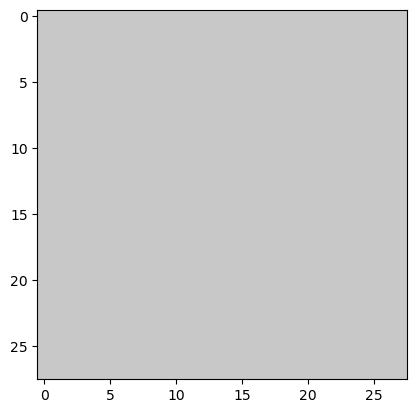

In [238]:
import matplotlib.pyplot as plt
img = np.full((28,28),255, dtype=np.uint8) #흰색
img = np.full((28,28),200, dtype=np.uint8) # 회색
#img = np.zeros((28,28), dtype=np.uint8)# 검정색
plt.imshow(img, cmap='gray', vmin=0, vmax=255)

plt.show

In [1]:
import numpy as np
np.empty((3,2))

array([[4.22787460e-307, 4.22791874e-307],
       [1.06101376e-312, 2.22519099e-307],
       [2.33647355e-307, 6.23040373e-307]])

## 2.3 랜덤값을 갖는 배열 만들기 
- n차원 배열 
- np.random.random(tup):0부터 1 미만의 균등분포를 갖는 tup 사이즈 랜덤값
- np.random.uniform(low-0, high=1.0, size=tup) : low부터 high미만까지 균등분포를 갖는 랜덤값
- np.random.normal(loc =0.0. scale = 1.0, size=tup): 평균loc, 표준편차 scale을 갖는 정규분포 랜덤값 


- 1차원 배열 
- np.random.rand(n): 균등분포의 1차원 0~1 난수 배열 발생 (난수가 n 개)
- np.random.randn(n) : 표준정규분포 (평균0, 표준편차가 1인 정규분포)의 1차원 난수 배열 발생(나수n개) 
- np.random.randint(n) : 0부터 n미만의 정수난수 1개 발생  == random.randint(0, n-1)
- np.random.randint(from, to) : from부터 to 미만의 정수 난수 1개 발생
                                == random.randint(from,to-1) 

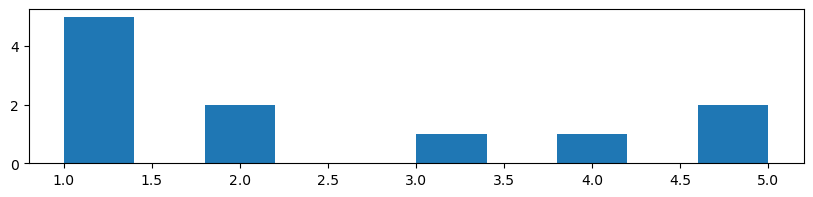

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,2)) #그래프 사이즈 조절 
x=[1,2,3,1,1,1,2,1,4,5,5]
plt.hist(x,bins=10 )
plt.show()

In [3]:
np.random.rand(100000)

array([0.36799382, 0.05137288, 0.75750277, 0.58682012, 0.56745292,
       0.62821534])

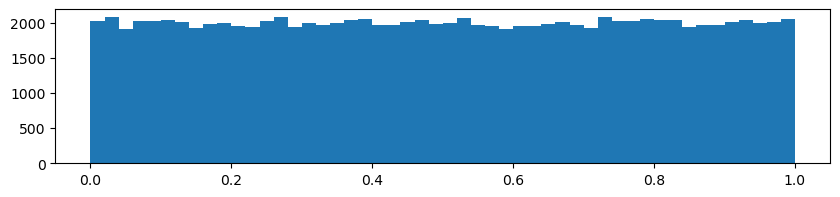

In [25]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,2)) #그래프 사이즈 조절 
# x=np.random.random(10000)
# x=np.random.uniform(3,10, 1000000)
x=np.random.rand(100000)
plt.hist(x,bins=50 )
plt.show()

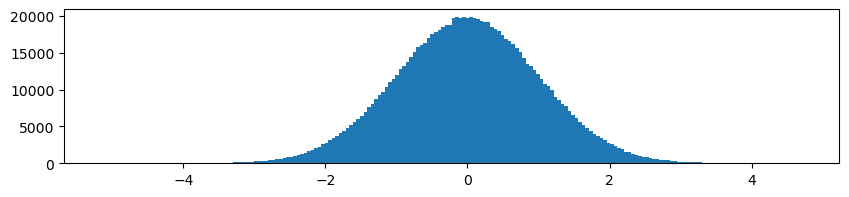

In [30]:
import matplotlib.pyplot as plt # 그래프 사이즈 조절 
plt.figure(figsize=(10,2))
x = np.random.normal(50, 10, 1000000)#정규분포
x = np.random.normal(0,1,1000000)#표준정규분포
x = np.random.randn(1000000)#표준정규분포
plt.hist(x,bins=200 )
plt.show()

# 4절. 복사와 뷰
## 4.1할당 

In [141]:
#스칼라 변수
a=10
b-a
print('a와 b의 주소:', id(a), id(b))
print('수정후 a와 b의 데이터:', a, b)

a와 b의 주소: 1580959400464 1580959400112
수정후 a와 b의 데이터: 10 -1


In [142]:
# 배열 
a = np.arange(12)
a

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [143]:
b=a 
#b =np.array(a, copy=False)와 같음
a.shape, type(a), a.ndim, id(a)

((12,), numpy.ndarray, 1, 1581077777264)

In [ ]:
a.shape, type(a), a.ndim, id(a)

In [144]:
a is b 

True

In [145]:
a ==b # 요소별 비교 

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

In [147]:
np.all(a==b) # np.all() array 배열 안에 모든 값이 True인지 여부 

True

In [148]:
b.shape = (3,4)

In [149]:
a.shape, type(a), a.ndim, id(a)

((3, 4), numpy.ndarray, 2, 1581077777264)

In [150]:
a.shape

(3, 4)

In [151]:
a


array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

## 4.2 뷰(View): 얕은 복사 

In [153]:
a = np.arange(12).reshape(3,4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [155]:
c = a.view() #얕은 복사 
c

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [156]:
id(a), id(c)

(1581079615920, 1581091006832)

In [157]:
a==c

array([[ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True]])

In [158]:
np.all(a==c)

True

In [159]:
a is c

False

In [160]:
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [163]:
c.shape =(2,6)
c

array([[ 0,  1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10, 11]])

In [164]:
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [168]:
#배열 복사본 c의 특정 요소만 변경 
c[1,::2]=-99
c

array([[  0,   1,   2,   3,   4,   5],
       [-99,   7, -99,   9, -99,  11]])

In [173]:
a

array([[99, 88, 77, 85],
       [88, 71, 77, 77],
       [99, 99, 99, 99]])

In [204]:
#슬라이싱이 될때 뷰가 반환됨 (shape, dtype 변경 외에는 원본도 변경 )
a= np.array([[99,88,77,85],
            [88,71,77,77],
           [99,99,99,99],])
X = a[:,:-1]
a

array([[99, 88, 77, 85],
       [88, 71, 77, 77],
       [99, 99, 99, 99]])

In [205]:
X = a[:,:-1].copy()
X

array([[99, 88, 77],
       [88, 71, 77],
       [99, 99, 99]])

In [203]:
X[0:2, -1] =1
X[-1,-1]=-1
X

array([[ 1,  1,  1],
       [ 1,  1,  1],
       [ 1,  1, -1]])

In [181]:
a

array([[99, 88,  1, 85],
       [88, 71,  1, 77],
       [99, 99, -1, 99]])

## 4.3 깊은 복사

In [188]:
a=np.array([[99, 88, 77, 85],
       [88, 71, 77, 77],
       [99, 99, 99, 99]])
a

array([[99, 88, 77, 85],
       [88, 71, 77, 77],
       [99, 99, 99, 99]])

In [200]:
# x = a[:,:-1]# 얕은복사  (view 생성)
X= a[:,:-1].copy() #깊은 복사
X

array([[99, 88, 77],
       [88, 71, 77],
       [99, 99, 99]])

In [201]:
X[:,0:2]=1
X[-1,-1]=-1
X

array([[ 1,  1, 77],
       [ 1,  1, 77],
       [ 1,  1, -1]])

In [202]:
a

array([[99, 88, 77, 85],
       [88, 71, 77, 77],
       [99, 99, 99, 99]])